In [1]:
import numpy as np
import xarray as xr
import os 
import glob

In [2]:
#Final so far
import dask
from dask.distributed import Client
import os

scheduler_file = os.path.join(os.environ["PSCRATCH"], "scheduler_jupyter.json")

dask.config.config["distributed"]["dashboard"]["link"] = "{JUPYTERHUB_SERVICE_PREFIX}proxy/{host}:{port}/status" 

client = Client(scheduler_file=scheduler_file)
client

<Client: 'tcp://10.249.1.192:8786' processes=12 threads=252, memory=468.93 GiB>

In [3]:
path = "/pscratch/sd/k/kquagra/Side_Jobs/Diya Collab/Categorised_ERA5_WCNA_data/"

# Match all years from 2001 to 2017
file_names = sorted(
    sum(
        [glob.glob(path + f"AR_categorization_{year}*.nc") for year in range(2001, 2018)],
        []
    )
)

In [ ]:
ds = xr.open_mfdataset(file_names)
#print(ds)
AR_event_category = ds['AR_event_category']
print(AR_event_category)

In [ ]:
precip_path = "/pscratch/sd/d/dkamnani/Results_data/training_input_precip_*.nc"
ds_precip = xr.open_mfdataset(precip_path)
print(ds_precip)

In [ ]:
ds_precip = ds_precip['tp']

In [ ]:
#Convert from meters to mm. 
ds_precip = ds_precip * 1000.0
ds_precip.attrs['units'] = 'mm'

In [ ]:
matching_times = np.intersect1d(ds_precip.time.values, AR_event_category.time.values)
ds_precip = ds_precip.sel(time=matching_times)
print(ds_precip)

In [ ]:
AR_event_category = AR_event_category.sel(time=matching_times)
print(AR_event_category)

In [ ]:
#Matching array dimension
ds_precip = ds_precip.sel(latitude=slice(60, 0))
ds_precip = ds_precip.assign_coords(
    longitude=(((ds_precip.longitude + 180) % 360) - 180)
)

# 2. Sort longitudes (important after reassignment to avoid disordered coords)
ds_precip = ds_precip.sortby('longitude')

# 3. Select the desired longitude range
ds_precip = ds_precip.sel(longitude=slice(-160, -50))

In [ ]:
print(ds_precip)

In [ ]:
#Teca data 
"""
teca_path = "/global/cfs/cdirs/m4374/catalogues/raw_catalogue_files/observations/teca_era5/ERA5_BARD_AR.2005*.nc4"
teca_data = xr.open_mfdataset(teca_path)
teca_data = teca_data["ar_binary_tag"]
print(teca_data)
"""
# Update path to include all years from 2001 to 2017
teca_path = "/global/cfs/cdirs/m4374/catalogues/raw_catalogue_files/observations/teca_era5/ERA5_BARD_AR.20*.nc4"

# Open all files and subset by time
teca_data = xr.open_mfdataset(teca_path, combine='by_coords')
teca_data = teca_data["ar_binary_tag"]

# Select years 2001 to 2017
teca_data = teca_data.sel(time=slice("2001-01-01", "2017-12-31"))

print(teca_data)

In [ ]:
time = ds_precip.time.values
teca_data = teca_data.sel(time  = time)
print(teca_data)

In [ ]:
teca_data = teca_data.sel(latitude=slice(0, 60))
teca_data = teca_data.sortby('latitude', ascending = False)

teca_data = teca_data.assign_coords(longitude=(((teca_data.longitude + 180) % 360) - 180))
# 2. Sort longitudes (important after reassignment to avoid disordered coords)
teca_data = teca_data.sortby('longitude')

# 3. Select the desired longitude range
teca_data = teca_data.sel(longitude=slice(-160, -50))
print(teca_data)

In [ ]:
# Remap categories: 6 and 7 -> 5
AR_event_category_remap = xr.where(AR_event_category.isin([6, 7]), 5, AR_event_category)

In [ ]:
import numpy as np
import xarray as xr

# --- 1. Mask precip by AR presence ---
precip_ar = ds_precip.where(teca_data == 1)

# --- 2. Define AR categories (1–16) ---
co_categories = np.arange(1, 6)
precip_distributions = []

for cat in co_categories:
    print(cat)
    # Mask precip where the category = cat
    cat_precip = precip_ar.where(AR_event_category == cat)
    
    # Flatten + drop NaNs
    values = cat_precip.values.flatten()
    values = values[~np.isnan(values)]
    
    precip_distributions.append(values)

# precip_distributions is now a list of arrays, one per category



In [ ]:
print(precip_distributions)

In [ ]:
import numpy as np

# Save
np.save("precip_distributions.npy", precip_distributions, allow_pickle=True)

# Load back
loaded_precip_distributions = np.load("precip_distributions.npy", allow_pickle=True)

print(type(loaded_precip_distributions))  # <class 'numpy.ndarray'>
print(type(loaded_precip_distributions[0]))  # <class 'numpy.ndarray'>


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# Draw boxplot
ax.boxplot(precip_distributions, positions=co_categories, widths=0.6,
           patch_artist=True, showfliers=False)  # patch_artist=True fills boxes

# Axis labels & title
ax.set_xlabel("AR Category", fontsize=12)
ax.set_ylabel("Precipitation (mm/day)", fontsize=12)
ax.set_title("Precipitation Distribution by AR Category", fontsize=14)

# Make x-axis ticks match categories
ax.set_xticks(co_categories)

plt.tight_layout()
plt.show()


## Seasonally

In [ ]:
import numpy as np
import xarray as xr
import pandas as pd

# --- 1. Mask precip by AR presence ---
precip_ar = ds_precip.where(teca_data == 1)

# --- 2. Define AR categories (1–7 here) ---
co_categories = np.arange(1, 6)

# --- 3. Define seasons ---
season_names = {
    12: "DJF", 1: "DJF", 2: "DJF",
    3: "MAM", 4: "MAM", 5: "MAM",
    6: "JJA", 7: "JJA", 8: "JJA",
    9: "SON", 10: "SON", 11: "SON",
}

# --- 4. Collect results ---
seasonal_distributions = {}

for season in ["DJF", "MAM", "JJA", "SON"]:
    print(season)
    precip_distributions = []
    # Select times for this season
    season_mask = [season_names[pd.Timestamp(t).month] == season 
                   for t in precip_ar["time"].values]
    precip_season = precip_ar.isel(time=season_mask)
    category_season = AR_event_category.isel(time=season_mask)
    
    for cat in co_categories:
        print(cat)
        # Mask precip where the category = cat
        cat_precip = precip_season.where(category_season == cat)
        
        # Flatten + drop NaNs
        values = cat_precip.values.flatten()
        values = values[~np.isnan(values)]
        
        precip_distributions.append(values)
    
    seasonal_distributions[season] = precip_distributions


In [ ]:
print(seasonal_distributions)

In [ ]:
import pandas as pd

all_records = []

for season, cat_arrays in seasonal_distributions.items():
    for cat, arr in enumerate(cat_arrays, start=1):  # category numbers 1–7
        df_temp = pd.DataFrame({
            "precip": arr,
            "season": season,
            "category": cat
        })
        all_records.append(df_temp)

# Concatenate into one DataFrame
df_out = pd.concat(all_records, ignore_index=True)

# Save to CSV
df_out.to_csv("seasonal_precip_distributions.csv", index=False)
print("Saved to seasonal_precip_distributions.csv")

In [ ]:
import pandas as pd

all_records = []

for season, cat_arrays in seasonal_distributions.items():
    for cat, arr in enumerate(cat_arrays, start=1):  # category numbers 1–7
        df_temp = pd.DataFrame({
            "precip": arr,
            "season": season,
            "category": cat
        })
        all_records.append(df_temp)

# Concatenate into one DataFrame
df_out = pd.concat(all_records, ignore_index=True)

# Save to CSV
df_out.to_csv("seasonal_precip_distributions.csv", index=False)
print("Saved to seasonal_precip_distributions.csv")


## Afterwards

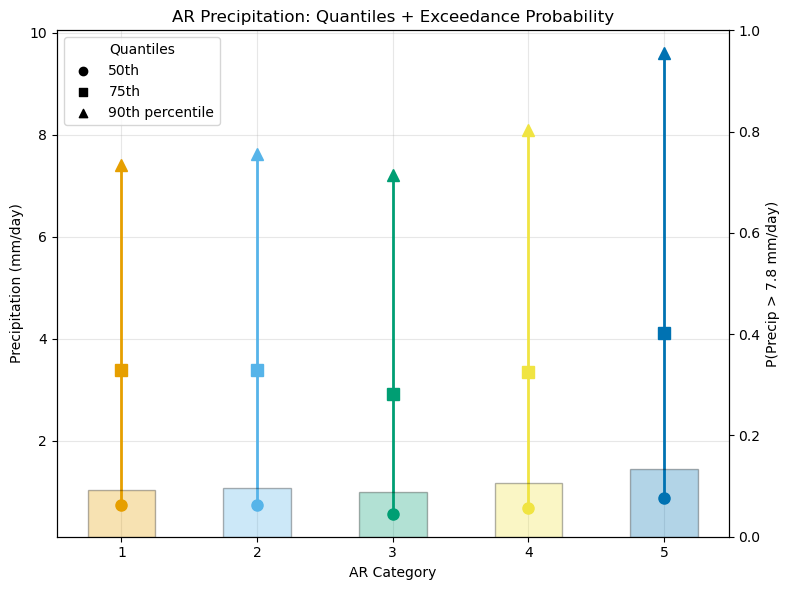

In [2]:
import numpy as np
import matplotlib.pyplot as plt

precip_arr = np.load("precip_distributions.npy", allow_pickle=True)
categories = np.arange(1, len(precip_arr) + 1)

# -------------------
# Color setup
# -------------------
colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2"]
color_map = {c: colors[i] for i, c in enumerate(categories)}

# -------------------
# Quantiles
# -------------------
quantiles = []
for arr in precip_arr:
    q = np.quantile(arr, [0.5, 0.75, 0.9])
    quantiles.append(q)

quantiles = np.array(quantiles)  # shape (n_categories, 3)

# -------------------
# Exceedance probability
# -------------------
threshold = np.quantile(np.concatenate(precip_arr), 0.9)
exceedance = [np.mean(arr > threshold) for arr in precip_arr]

# -------------------
# Plot
# -------------------
fig, ax1 = plt.subplots(figsize=(8, 6))

quantile_markers = ['o', 's', '^']  # 50th, 75th, 90th
quantile_labels = ['50th', '75th', '90th percentile']

# Plot vertical lines per category and markers
for i, c in enumerate(categories):
    # vertical line connecting quantiles for this category
    ax1.plot([c]*3, quantiles[i], linestyle='-', color=color_map[c], linewidth=2)
    
    # markers for each quantile
    for j in range(3):
        ax1.plot(c, quantiles[i, j],
                 marker=quantile_markers[j],
                 color=color_map[c],
                 markersize=8,
                 linestyle='')  # no extra line

ax1.set_xlabel("AR Category")
ax1.set_ylabel("Precipitation (mm/day)", color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Exceedance probability (right y-axis)
ax2 = ax1.twinx()
ax2.bar(categories, exceedance, color=[color_map[c] for c in categories],
        alpha=0.3, edgecolor='black', width=0.5)
ax2.set_ylabel(f"P(Precip > {threshold:.1f} mm/day)", color='black')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='y', labelcolor='black')

# Title, grid, and legends
ax1.set_title("AR Precipitation: Quantiles + Exceedance Probability")
ax1.grid(True, alpha=0.3)
ax1.set_xticks(categories)

# Add legend for quantiles (markers only)
for j, label in enumerate(quantile_labels):
    ax1.scatter([], [], marker=quantile_markers[j], color='black', label=label)
ax1.legend(title="Quantiles", loc='upper left')

plt.tight_layout()
plt.show()


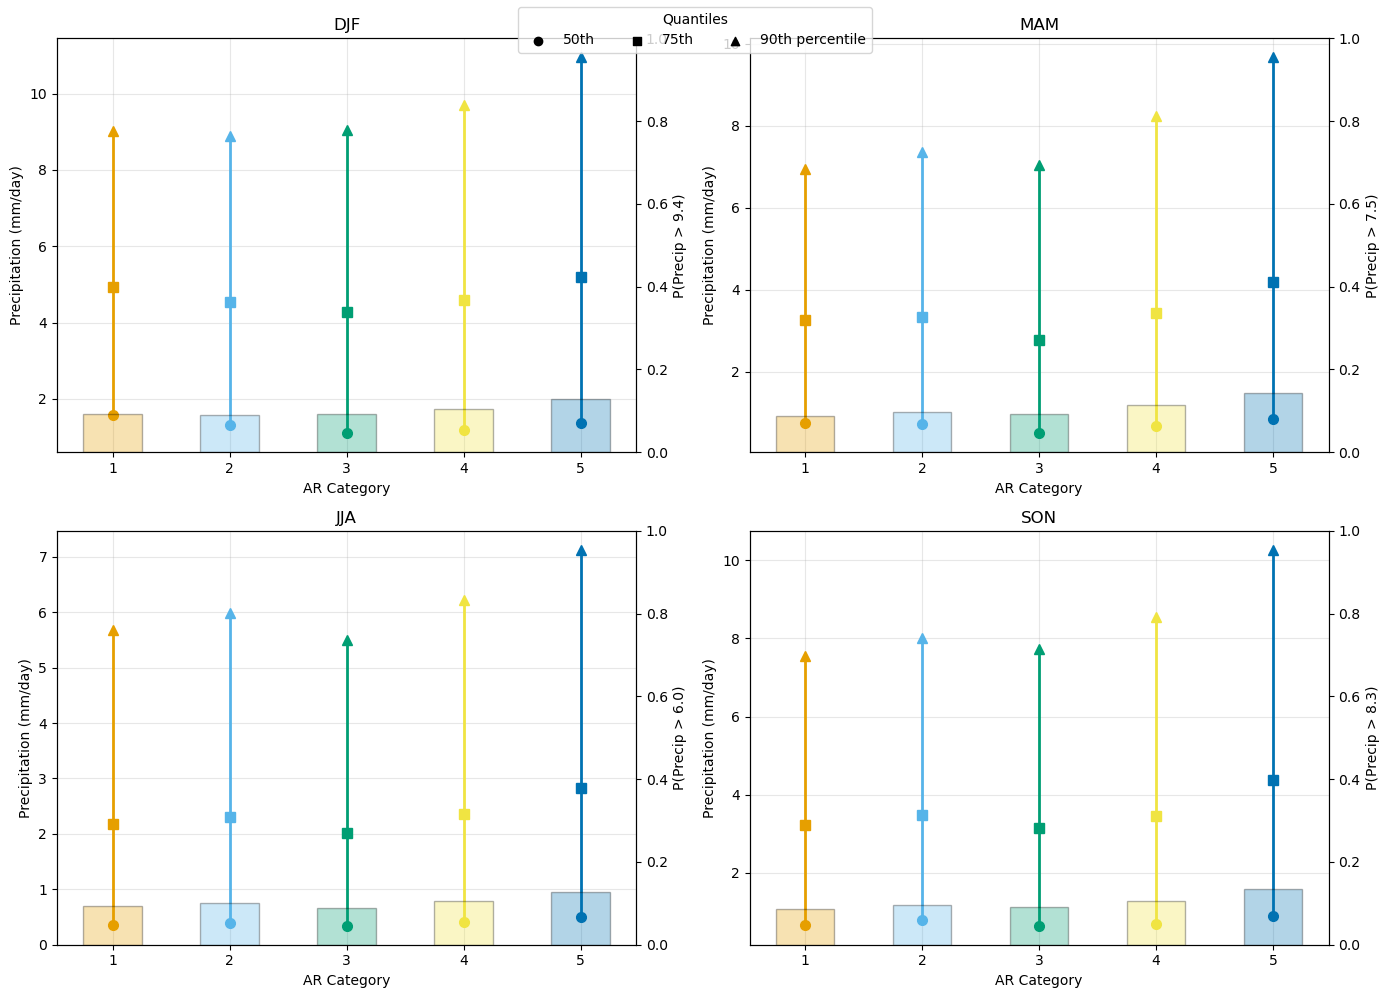

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------
# Load CSV
# -------------------
df = pd.read_csv("seasonal_precip_distributions.csv")

seasons = ["DJF", "MAM", "JJA", "SON"]
categories = sorted(df["category"].unique())

# -------------------
# Color setup
# -------------------
colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2"]
color_map = {c: colors[i] for i, c in enumerate(categories)}

quantile_markers = ['o', 's', '^']
quantile_labels = ['50th', '75th', '90th percentile']

# -------------------
# Create subplots
# -------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# -------------------
# Loop over seasons
# -------------------
for idx, season in enumerate(seasons):
    ax1 = axes[idx]
    
    df_season = df[df["season"] == season]
    
    # Build precip_arr like your original structure
    precip_arr = []
    for cat in categories:
        arr = df_season[df_season["category"] == cat]["precip"].values
        precip_arr.append(arr)
    
    # --- Quantiles ---
    quantiles = []
    for arr in precip_arr:
        if len(arr) > 0:
            q = np.quantile(arr, [0.5, 0.75, 0.9])
        else:
            q = [np.nan, np.nan, np.nan]
        quantiles.append(q)
    
    quantiles = np.array(quantiles)
    
    # --- Threshold (season-specific) ---
    all_vals = df_season["precip"].values
    threshold = np.quantile(all_vals, 0.9)
    
    exceedance = [
        np.mean(arr > threshold) if len(arr) > 0 else np.nan
        for arr in precip_arr
    ]
    
    # --- Plot quantiles ---
    for i, c in enumerate(categories):
        ax1.plot([c]*3, quantiles[i], linestyle='-', color=color_map[c], linewidth=2)
        
        for j in range(3):
            ax1.plot(c, quantiles[i, j],
                     marker=quantile_markers[j],
                     color=color_map[c],
                     markersize=7,
                     linestyle='')
    
    ax1.set_title(season)
    ax1.set_xlabel("AR Category")
    ax1.set_ylabel("Precipitation (mm/day)")
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(categories)
    
    # --- Exceedance (secondary axis) ---
    ax2 = ax1.twinx()
    ax2.bar(categories, exceedance,
            color=[color_map[c] for c in categories],
            alpha=0.3, edgecolor='black', width=0.5)
    
    ax2.set_ylim(0, 1)
    ax2.set_ylabel(f"P(Precip > {threshold:.1f})")

# -------------------
# Shared legend (quantiles)
# -------------------
for j, label in enumerate(quantile_labels):
    axes[0].scatter([], [], marker=quantile_markers[j], color='black', label=label)

fig.legend(title="Quantiles", loc="upper center", ncol=3)

plt.tight_layout()
plt.show()

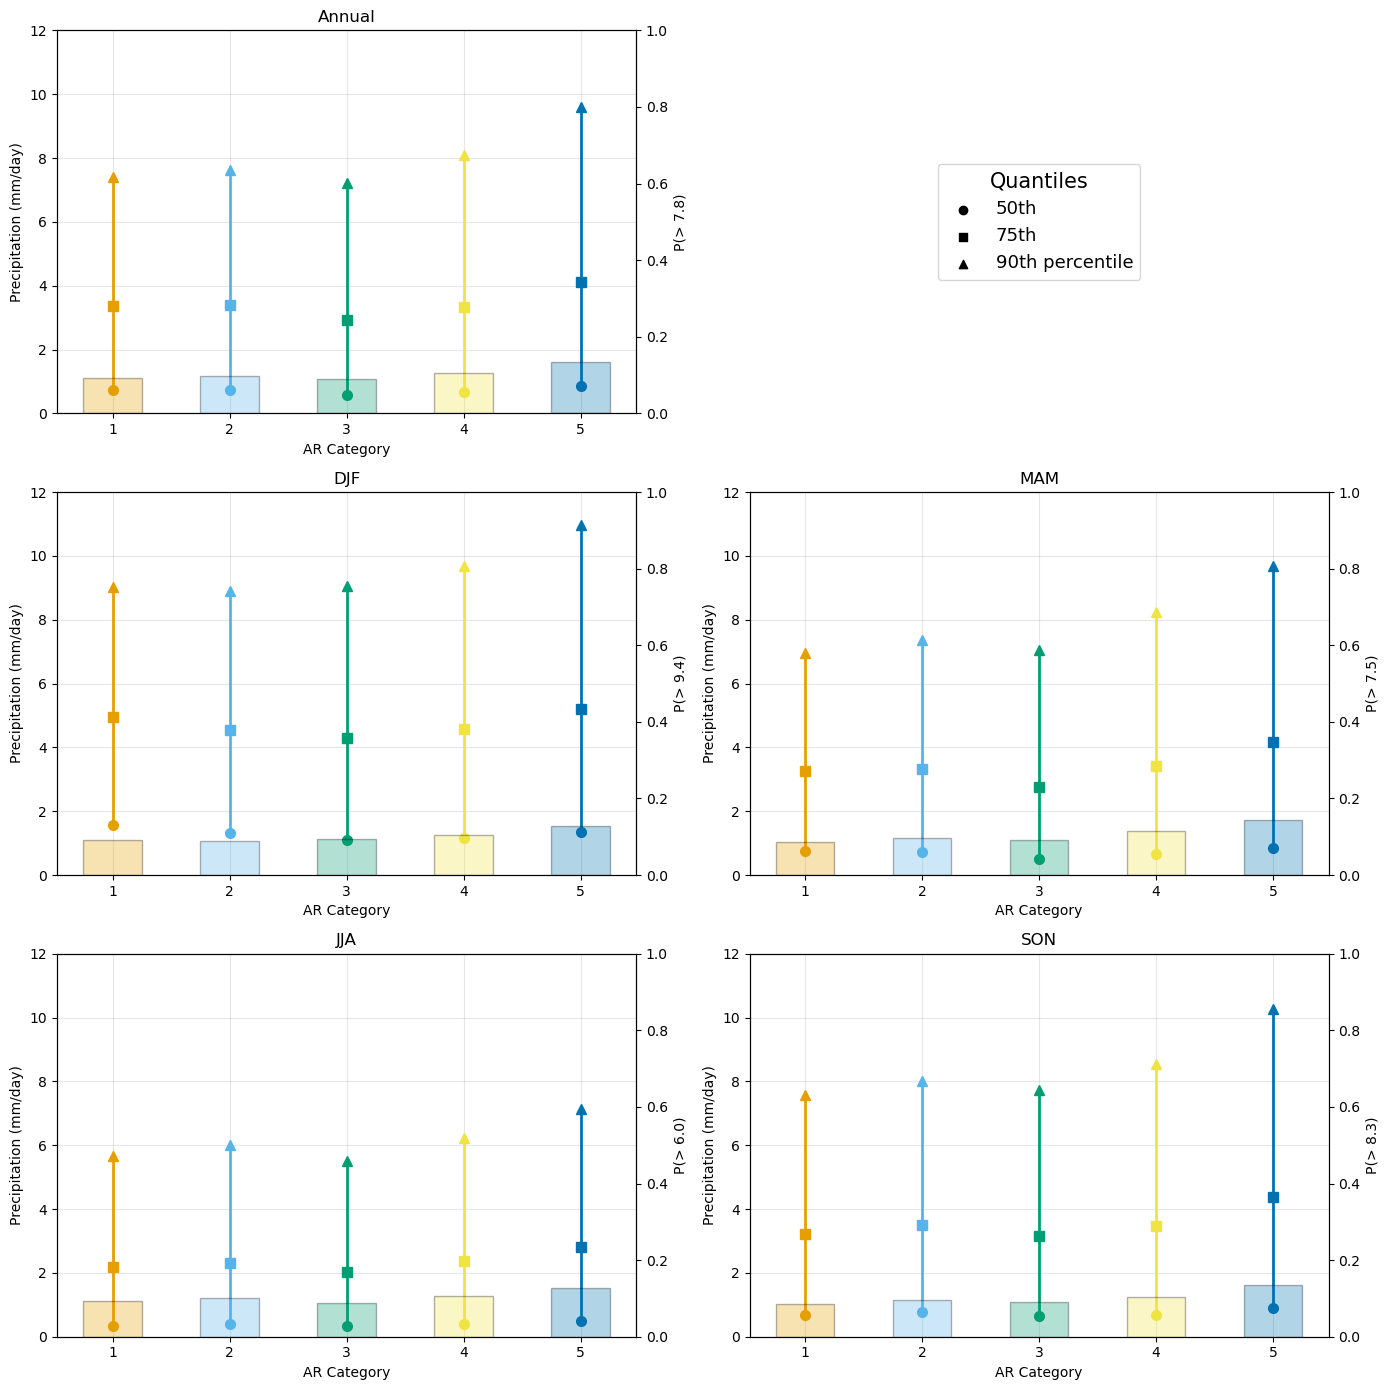

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------
# Load data
# -------------------
df = pd.read_csv("seasonal_precip_distributions.csv")
precip_arr_annual = np.load("precip_distributions.npy", allow_pickle=True)

categories = np.arange(1, len(precip_arr_annual) + 1)
seasons = ["DJF", "MAM", "JJA", "SON"]

# -------------------
# Color setup
# -------------------
colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2"]
color_map = {c: colors[i] for i, c in enumerate(categories)}

quantile_markers = ['o', 's', '^']
quantile_labels = ['50th', '75th', '90th percentile']

# -------------------
# GLOBAL Y-LIMIT (IMPORTANT)
# -------------------
all_annual_vals = np.concatenate(precip_arr_annual)
all_seasonal_vals = df["precip"].values
all_vals = np.concatenate([all_annual_vals, all_seasonal_vals])

global_ymax = np.quantile(all_vals, 0.99)

# -------------------
# Create figure (3x2)
# -------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

# =========================================================
# 🔵 ANNUAL (axes[0])
# =========================================================
ax1 = axes[0]

quantiles = []
for arr in precip_arr_annual:
    q = np.quantile(arr, [0.5, 0.75, 0.9])
    quantiles.append(q)
quantiles = np.array(quantiles)

all_vals_annual = np.concatenate(precip_arr_annual)
threshold = np.quantile(all_vals_annual, 0.9)
exceedance = [np.mean(arr > threshold) for arr in precip_arr_annual]

for i, c in enumerate(categories):
    ax1.plot([c]*3, quantiles[i], color=color_map[c], linewidth=2)
    
    for j in range(3):
        ax1.plot(c, quantiles[i, j],
                 marker=quantile_markers[j],
                 color=color_map[c],
                 markersize=7,
                 linestyle='')

ax1.set_title("Annual")
ax1.set_xlabel("AR Category")
ax1.set_ylabel("Precipitation (mm/day)")
ax1.set_ylim(0, 12)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(categories)

ax2 = ax1.twinx()
ax2.bar(categories, exceedance,
        color=[color_map[c] for c in categories],
        alpha=0.3, edgecolor='black', width=0.5)
ax2.set_ylim(0, 1)
ax2.set_ylabel(f"P(> {threshold:.1f})")

# =========================================================
# 🔲 LEGEND PANEL (axes[1])
# =========================================================
axes[1].axis("off")

for j, label in enumerate(quantile_labels):
    axes[1].scatter([], [], marker=quantile_markers[j], color='black', label=label)

axes[1].legend(
    title="Quantiles",
    loc="center",
    fontsize=13,
    title_fontsize=15
)

# =========================================================
# 🟢 SEASONAL PANELS
# =========================================================
for idx, season in enumerate(seasons):
    ax1 = axes[2 + idx]
    
    df_season = df[df["season"] == season]
    
    precip_arr = []
    for cat in categories:
        arr = df_season[df_season["category"] == cat]["precip"].values
        precip_arr.append(arr)
    
    # Quantiles
    quantiles = []
    for arr in precip_arr:
        if len(arr) > 0:
            q = np.quantile(arr, [0.5, 0.75, 0.9])
        else:
            q = [np.nan, np.nan, np.nan]
        quantiles.append(q)
    quantiles = np.array(quantiles)
    
    # Threshold
    all_vals_season = df_season["precip"].values
    threshold = np.quantile(all_vals_season, 0.9)
    
    exceedance = [
        np.mean(arr > threshold) if len(arr) > 0 else np.nan
        for arr in precip_arr
    ]
    
    # Plot
    for i, c in enumerate(categories):
        ax1.plot([c]*3, quantiles[i], color=color_map[c], linewidth=2)
        
        for j in range(3):
            ax1.plot(c, quantiles[i, j],
                     marker=quantile_markers[j],
                     color=color_map[c],
                     markersize=7,
                     linestyle='')
    
    ax1.set_title(season)
    ax1.set_xlabel("AR Category")
    ax1.set_ylabel("Precipitation (mm/day)")
    ax1.set_ylim(0, 12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(categories)
    
    ax2 = ax1.twinx()
    ax2.bar(categories, exceedance,
            color=[color_map[c] for c in categories],
            alpha=0.3, edgecolor='black', width=0.5)
    
    ax2.set_ylim(0, 1)
    ax2.set_ylabel(f"P(> {threshold:.1f})")

# -------------------
# Clean layout
# -------------------
plt.tight_layout()
plt.savefig("Supplementary_Figure3.pdf", dpi=300, bbox_inches="tight")
plt.show()